In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

# Load the training dataset
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Garbage classification/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load the validation dataset
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Garbage classification/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load the test dataset
test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "Garbage classification/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # Important for evaluation
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
Found 2527 files belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [2]:
num_classes = len(class_names)

model = tf.keras.Sequential([
    # Input Layer & Rescaling
    tf.keras.layers.InputLayer(input_shape=(128, 128, 3)),
    tf.keras.layers.Rescaling(1./255),
    
    # First Convolutional Block
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Second Convolutional Block
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2, 2)),
    
    # Flatten and Dense Layers
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu'),
    
    # Output Layer
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/home/aztrek/Sem-6/.ai/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     3,686,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,706,246 (14.14 MB)

 Trainable params: 3,706,246 (14.14 MB)

 Non-trainable params: 0 (0.00 B)

In [3]:
# Apply Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True 
)

# Train the model
epochs = 100

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=epochs,
    callbacks=[early_stopping]
)

Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.4155 - loss: 1.4534 - val_accuracy: 0.5516 - val_loss: 1.2047
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5880 - loss: 1.1075 - val_accuracy: 0.5857 - val_loss: 1.0373
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7028 - loss: 0.8311 - val_accuracy: 0.7978 - val_loss: 0.6301
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7796 - loss: 0.6343 - val_accuracy: 0.8611 - val_loss: 0.4408
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8429 - loss: 0.4635 - val_accuracy: 0.8714 - val_loss: 0.3619
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8987 - loss: 0.3155 - val_accuracy: 0.9438 - val_loss: 0.1966
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9402 - loss: 0.2056 - val_accuracy: 0.9604 - val_loss: 0.1437
Epoch 8/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9612 - loss: 0.1396 - val_accuracy: 0

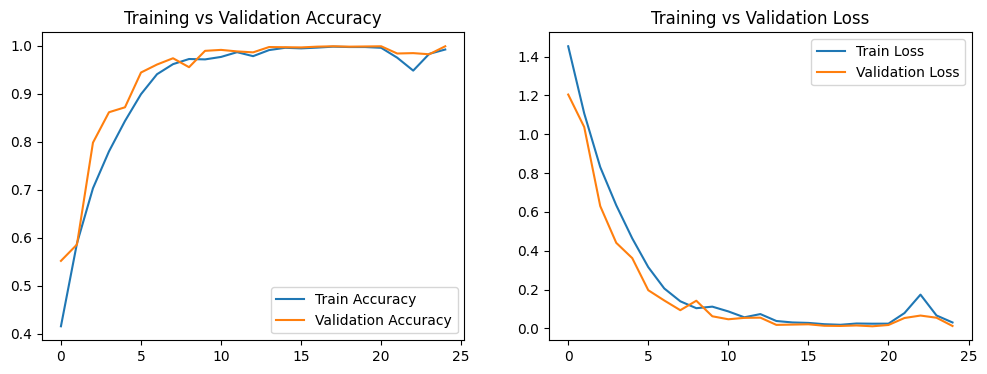

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9980 - loss: 0.0109
Test Accuracy: 0.9980


In [4]:
# Plot Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Training vs Validation Accuracy")

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training vs Validation Loss")
plt.show()

# Evaluate on test dataset
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Accuracy: {test_acc:.4f}")

In [5]:
# Load the pretrained MobileNetV2 model
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the pretrained layers
base_model.trainable = False

# Build the transfer learning model
tl_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(128, 128, 3)),
    tf.keras.layers.Rescaling(1./255), # Normalization
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(num_classes, activation='softmax')
])

tl_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Training Transfer Learning Model...")
tl_history = tl_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=20, # 20 is usually enough for TL, but you can set to 100 as per instructions
    callbacks=[early_stopping]
)

# Evaluate Transfer Learning model
tl_test_loss, tl_test_acc = tl_model.evaluate(test_dataset)
print(f"Transfer Learning Test Accuracy: {tl_test_acc:.4f}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 7s 1us/step
Training Transfer Learning Model...
Epoch 1/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 20s 142ms/step - accuracy: 0.5837 - loss: 1.1335 - val_accuracy: 0.7388 - val_loss: 0.7302
Epoch 2/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7713 - loss: 0.6426 - val_accuracy: 0.8085 - val_loss: 0.5444
Epoch 3/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8247 - loss: 0.5067 - val_accuracy: 0.8540 - val_loss: 0.4400
Epoch 4/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8599 - loss: 0.4290 - val_accuracy: 0.8892 - val_loss: 0.3660
Epoch 5/20
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8868 - loss: 0.3696 - val_accuracy: 0.8908 - val_loss: 0.3487
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7388 - loss: 0.7302
Transfer Learning Test Accuracy: 0.7388
